##  Section 1 - Machine Learning

In [39]:
import pandas as panda
from pandas import DataFrame
import matplotlib.pyplot as plot
import numpy as numpy
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# creating a dataframe from the nutrients dataset
df = panda.read_csv('dataset/e1_nutrients.csv')

#split the large dataset into training and test datasets
training_data_df, test_data_df = train_test_split(df, test_size=0.2, random_state=42)

filtered_training_df = training_data_df.copy()
original_df_copy = df.copy()

In [40]:
# we are passing the training dataset instead of the test data df as we want to keep test_data_df as a separate dataset to evaluate our model on after we have trained it on the training dataset
# get all values witihin the column depth from the dataframe
depth_values = filtered_training_df['Depth']
    
# because values in the depth column are repeated, i.e. numbers 0-60 are repeated multiple times, filter out the repeated values and get only the unique values, using .unique()
for depth in depth_values.unique():
    # because we currently have all values for the depth column, we want to narrow our focus to only values for the current depth 
    # so we copy the dataframe and filter it to only include the rows where the depth value is equal to the current depth value we are iterating over
    current_depth_values = filtered_training_df.loc[depth_values == depth].copy()
        
    # we want to get values for each chemical given a depth val
    # so we create a list of chemicals fromt he nutrients dataset we want to loop through, excluding NITRITE
    # we dont want to filter NITRITE since this is the chemical we want to predict
    # including outliers is helpful because it gives us a better idea of the range of values NITRITE can take, which is important for our prediction task
    chemical_list = ['NITRATE+NITRITE', 'AMMONIA', 'SILICATE', 'PHOSPHATE']
        
    # iterate through the chemical list 
    for chemical in chemical_list:
            
    # for each chemical, we want to get the values for that chemical at the current depth value we are iterating over
        depth_chemical_values = current_depth_values[chemical]
            
        # to remove the outliers, we have to caluclate the interquartile range IQR by finding the upper quartile Q3 and lower quartile Q1
        # numpy has a built-in function quantile-- the value 0.75 gives the upper range and 0.25 gives the lower range
        Q3 = depth_chemical_values.quantile(0.75)
        Q1 = depth_chemical_values.quantile(0.25)
            
        # subtracting the bigger quartile from the smaller quartile
        IQR = Q3 - Q1
            
        # we have to calculate higher bound and lower bound using the quartiles and IQR
        higher_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR
            
        for index, value in enumerate(depth_chemical_values):
            if value > higher_bound or value < lower_bound:
                depth_chemical_values.iloc[index] = None
            
            current_depth_values[chemical] = depth_chemical_values
        filtered_training_df.loc[depth_values == depth] = current_depth_values
cleaned_trained_df = filtered_training_df.dropna()

In [41]:
# scaling the data 
x_scaler = RobustScaler()
y_scaler = RobustScaler()
x_train = x_scaler.fit_transform(cleaned_trained_df.drop(columns=['NITRITE'])) # all but NITRITE
y_train = y_scaler.fit_transform(cleaned_trained_df[['NITRITE']]).ravel() # target (NITRITE)

# scaling test data
x_test = x_scaler.transform(test_data_df.drop(columns=['NITRITE']))
y_test = y_scaler.transform(test_data_df[['NITRITE']]).ravel()

filtered_df = filtered_training_df
scaled_df = cleaned_trained_df.copy().astype(float)
scale_columns = scaled_df.columns != "NITRITE"
scaled_df.loc[:, scale_columns] = x_train

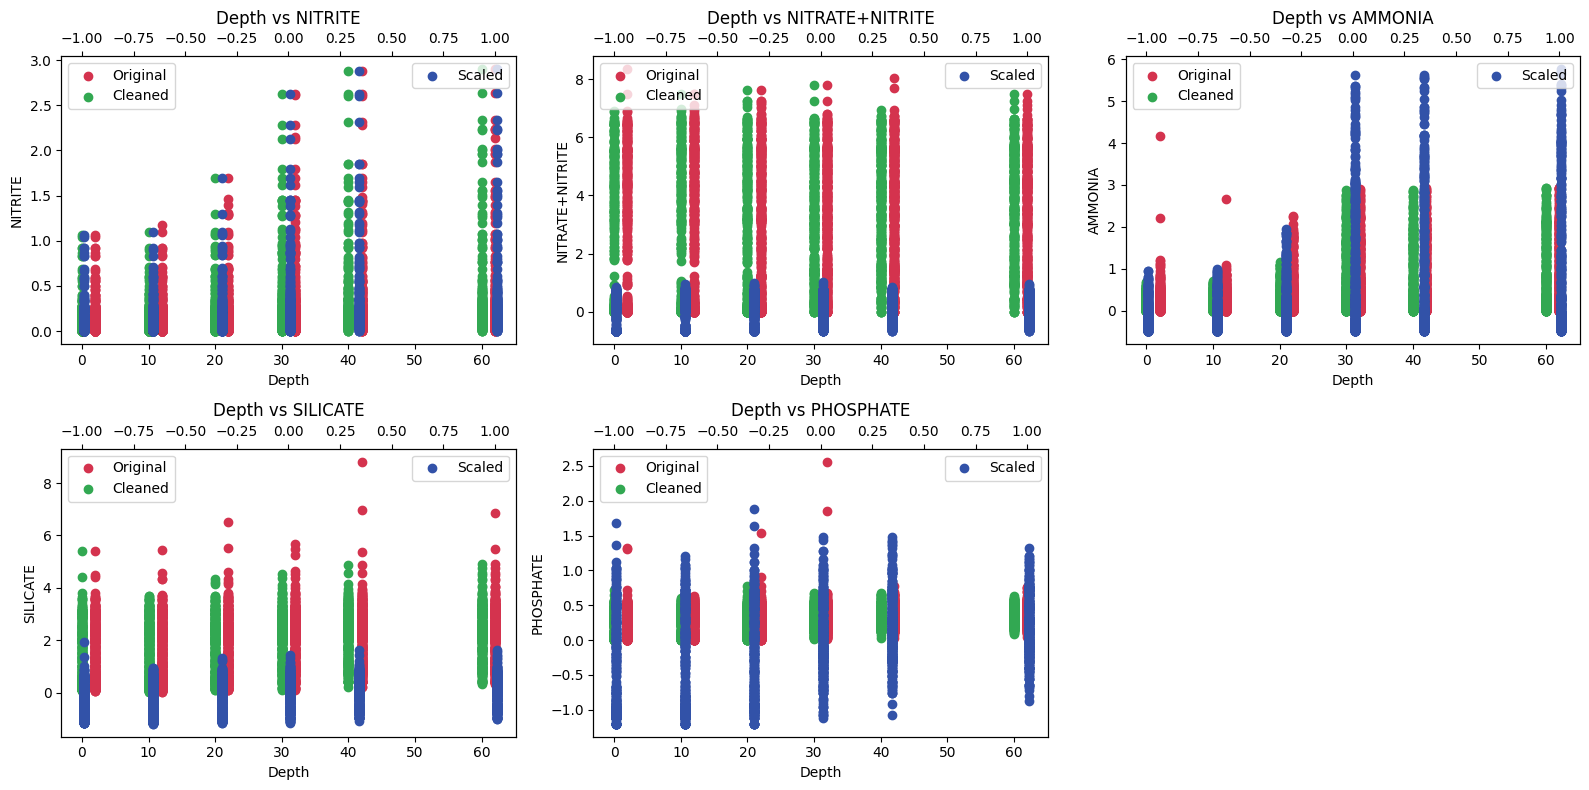

In [42]:
# scatter graphs to visualise the original data against the cleaned and scaled data
chemical_list = ['NITRITE', 'NITRATE+NITRITE', 'AMMONIA', 'SILICATE', 'PHOSPHATE']
    
fig, axes = plot.subplots(2, 3, figsize=(16, 8), sharex=False)
axes = axes.flatten()

for ax, chemical in zip(axes, chemical_list):
    ax.scatter(
        original_df_copy['Depth'] +2.0,
        original_df_copy[chemical],
        color='#d4334e',
        label='Original'
            
    )
    ax.scatter(
        cleaned_trained_df['Depth'],
        cleaned_trained_df[chemical],
        label='Cleaned',
        color='#32a852'
            
    )
    
    ax2 = ax.twiny()
    ax2.set_xlim(-1.1, 1.1)
        
    ax2.scatter(
        scaled_df['Depth']+0.01,
        scaled_df[chemical],
        label='Scaled',
        color='#3252a8'
    )

    ax.set_title(f'Depth vs {chemical}')
    ax.set_xlabel('Depth')
    ax.set_ylabel(chemical)
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
for ax in axes[len(chemical_list):]:
    ax.remove()
        
plot.tight_layout()
plot.show()

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
   
linear_regression_model = LinearRegression()
random_forest_model = RandomForestRegressor(random_state=42)
neural_network_model = MLPRegressor(random_state=42, max_iter=2500)


"""Linear regression."""
# linear regression fit to the training data and making predictions on both the training and test data
linear = linear_regression_model.fit(x_train, y_train)
linear_train_prediction = linear.predict(x_train)
linear_test_prediction = linear.predict(x_test)
      
# linear training score
train_linear_mse = mean_squared_error(y_train, linear_train_prediction)
test_linear_mse = mean_squared_error(y_test, linear_test_prediction)

In [44]:
"""Random forest regression."""
# fitting the random forest model to the training data and making predictions on both the training and test data
rf = random_forest_model.fit(x_train, y_train)
random_forest_train_prediction = rf.predict(x_train)
random_forest_test_prediction = rf.predict(x_test)

# random forest training score
random_forest_train_mse = mean_squared_error(y_train, random_forest_train_prediction)
random_forest_test_mse = mean_squared_error(y_test, random_forest_test_prediction)

# random forest training score
random_forest_train_mse = mean_squared_error(y_train, random_forest_train_prediction)
random_forest_test_mse = mean_squared_error(y_test, random_forest_test_prediction)

In [46]:
""""Obtaining the best hyperparameters for the random forest model using RandomizedSearchCV."""

from sklearn.model_selection import RandomizedSearchCV

untuned_rf = RandomForestRegressor(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['sqrt', 'log2', None, 0.5, 0.75],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(untuned_rf, param_distributions=param_dist, n_iter=150, cv=5, n_jobs=-1, scoring='neg_mean_squared_error', return_train_score=True)
random_search.fit(x_train, y_train)
best_rf_params = random_search.best_params_
print("Best hyperparameters for Random Forest:", best_rf_params)

Best hyperparameters for Random Forest: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20, 'bootstrap': False}


In [47]:
"""Fitting the tuned random forest model with the best hyperparameters."""
from sklearn.ensemble import RandomForestRegressor

tuned_rf = RandomForestRegressor(**best_rf_params, random_state=42)
tuned_rf.fit(x_train, y_train)

tuned_rf_train_prediction = tuned_rf.predict(x_train)
tuned_rf_test_prediction = tuned_rf.predict(x_test)

# training score for tuned rf 
tuned_rf_train_mse = mean_squared_error(y_train, tuned_rf_train_prediction)
tuned_rf_test_mse = mean_squared_error(y_test, tuned_rf_test_prediction)

In [48]:
"""Neural Network regression (NOT TUNED)."""
# fitting the neural network model to the training data and making predictions on both the training and test data
neural = neural_network_model.fit(x_train, y_train)
neural_network_train_prediction = neural.predict(x_train)
neural_network_test_prediction = neural.predict(x_test)

# training score for neural network
neural_network_train_mse = mean_squared_error(y_train, neural_network_train_prediction)
neural_network_test_mse = mean_squared_error(y_test, neural_network_test_prediction)

In [49]:
"""Obtaining the best parameters for the tuned neural network model by using RandomisedSearchV."""

untuned_nn = MLPRegressor(random_state=42, max_iter=2500)
nn_param_dist = {
    'hidden_layer_sizes': [(100, 50), (50, 50)],
    'activation': ['identity', 'relu', 'tanh'],
    'solver': ['adam', 'sgd', 'lbfgs'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

nn_random_search = RandomizedSearchCV(
    untuned_nn, 
    param_distributions=nn_param_dist, 
    n_iter=150, 
    cv=5, 
    n_jobs=-1, 
    scoring='neg_mean_squared_error', 
    return_train_score=True
)
nn_random_search.fit(x_train, y_train)
best_nn_params = nn_random_search.best_params_
print("Best hyperparameters for Neural Network:", best_nn_params)

c:\Users\khyat\Documents\2002 70%\venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 108 is smaller than n_iter=150. Running 108 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best hyperparameters for Neural Network: {'solver': 'sgd', 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50, 50), 'alpha': 0.01, 'activation': 'relu'}


In [50]:
"""TUNED neural network regression."""
tuned_nn_model = MLPRegressor(**best_nn_params, random_state=42, max_iter=2500)
tuned_nn_model.fit(x_train, y_train)
tuned_nn_train_prediction = tuned_nn_model.predict(x_train)
tuned_nn_test_prediction = tuned_nn_model.predict(x_test)

# training score for tuned neural network
tuned_nn_train_mse = mean_squared_error(y_train, tuned_nn_train_prediction)
tuned_nn_test_mse = mean_squared_error(y_test, tuned_nn_test_prediction)

In [51]:
# cross validation for all models of regression
linear_cross_val = cross_val_score(linear_regression_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
untuned_rf_cross_val = cross_val_score(random_forest_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
tuned_rf_cross_val = cross_val_score(tuned_rf, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
nn_cross_val = cross_val_score(neural_network_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')
tuned_nn_cross_val = cross_val_score(tuned_nn_model, x_train, y_train, cv=5, scoring='neg_mean_squared_error')

# create a dictionary to organise the values to their respective model names for the panda DataFrame
scores_data = {
    'model name': ["Linear Regression", "Random Forest Regression",  "Tuned Random Forest Regression", "Neural Network Regression", "Tuned Neural Network Regression"],
    'cross_value_mean': [linear_cross_val.mean(), untuned_rf_cross_val.mean(), tuned_rf_cross_val.mean(), nn_cross_val.mean(), tuned_nn_cross_val.mean()],
    'train_mse': [train_linear_mse, random_forest_train_mse, tuned_rf_train_mse, neural_network_train_mse, tuned_nn_train_mse],
    'test_mse': [test_linear_mse, random_forest_test_mse, tuned_rf_test_mse, neural_network_test_mse, tuned_nn_test_mse],
    'cross_value_std': [linear_cross_val.std(), untuned_rf_cross_val.std(), tuned_rf_cross_val.std(), nn_cross_val.std(), tuned_nn_cross_val.std()]
}

panda.DataFrame(scores_data).sort_values(by='test_mse')

,model name,cross_value_mean,train_mse,test_mse,cross_value_std
2,Tuned Random Forest Regression,-1.557403,0.086001,1.246734,0.204423
1,Random Forest Regression,-1.669358,0.204948,1.302411,0.177763
4,Tuned Neural Network Regression,-1.924233,1.501526,1.803311,0.146323
3,Neural Network Regression,-1.905816,1.667608,1.815494,0.124032
0,Linear Regression,-2.672020,2.660041,2.492813,0.326600


##  Section 2 - Optimisation

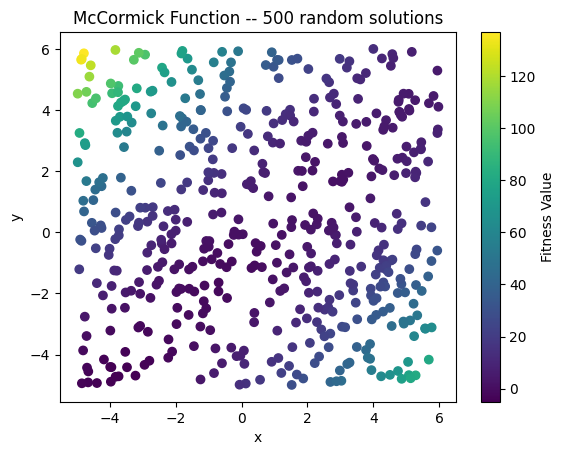

Best X value: 3.2420110142069927
Worst X value: -4.848541921902213
Best Y value: 2.3038832230338784
Worst Y value: -4.9397241200333575


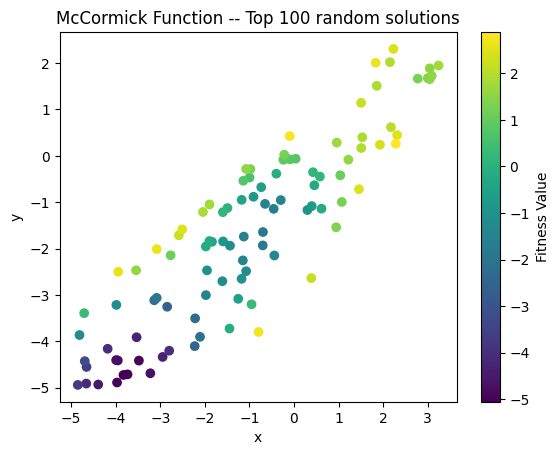

In [ ]:
"""Task 2.1-- Generate 500 random soluitions."""
import numpy as numpy
from numpy import sin, random
from matplotlib import pyplot as plot

# create the McCormick function
def mccormick_function(x, y):
    return numpy.sin(x + y) + (x - y)** 2 - (1.5*x) + (2.5*y) + 1

x_vals, y_vals, function_results = [], [], []

for i in range (501):
    x = numpy.random.uniform(-5, 6)
    y = numpy.random.uniform(-5, 6)
    
    result = mccormick_function(x, y)
    x_vals.append(x)
    y_vals.append(y)
    function_results.append(result)
    

# plotting results onto a scatter plot 
plot.scatter(x_vals, y_vals, c=function_results)
plot.title('McCormick Function -- 500 random solutions')
plot.colorbar(label='Fitness Value')
plot.xlabel('x')
plot.ylabel('y')
plot.show()

# narrowing down the search area from 500 solutions to the TOP 100 solutions
indexes_sorted = numpy.argsort(function_results)[:100]

top_100_x =[]
top_100_y = []
top_100_results = []

for index in indexes_sorted:
    top_100_x.append(x_vals[index])
    top_100_y.append(y_vals[index])
    top_100_results.append(function_results[index])
    
# to narrow search area, need to get the highest and lowest bounds for X and Y
best_x = max(top_100_x)
worst_x = min(top_100_x)
best_y = max(top_100_y)
worst_y = min(top_100_y)

# print statement check
print (f"Best X value: {best_x}")
print (f"Worst X value: {worst_x}")
print (f"Best Y value: {best_y}")
print (f"Worst Y value: {worst_y}")

# plotting only the top 100 from the 500 random solutions 
plot.scatter(top_100_x, top_100_y, c=top_100_results)
plot.title('McCormick Function -- Top 100 from 500 random solutions')
plot.colorbar(label='Fitness Value')
plot.xlabel('x')
plot.ylabel('y')
plot.show()

In [ ]:
"""Task 2.2"""
import numpy as numpy
from numpy import sum

class GaussianMutation:
    def mutate (self, a):
        mutate_rate = 0.1
        mutation = numpy.random.normal(0, mutate_rate) 
        return a + mutation
    
mutation_operator = GaussianMutation().mutate

def hill_climbing_alg(no_iterations, best_x, worst_x, best_y, worst_y):
    fitness_vals = []
    
    px = numpy.random.uniform(worst_x, best_x)
    py = numpy.random.uniform(worst_y, worst_y)
    
    cx = mutation_operator(px)
    cy = mutation_operator(py)
    
    for i in range(no_iterations):
        if mccormick_function(cx, cy) < mccormick_function(px, py):
            px, py = cx, cy
            fit_val = mccormick_function(px, py)
        fitness_vals.append(fit_val)    
            
        cx = mutation_operator(px)
        cy = mutation_operator(py)
    return fitness_vals

In [28]:
fitness_vals = hill_climbing_alg(200, best_x, best_y, worst_x, worst_y)

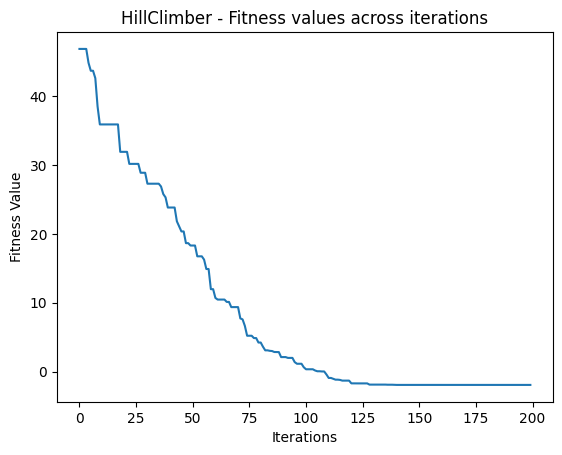

In [29]:
plot.plot(fitness_vals)
plot.title('HillClimber - Fitness values across iterations')
plot.xlabel('Iterations')
plot.ylabel('Fitness Value')
plot.show()

In [30]:
big_search_fitness_vals = hill_climbing_alg(200, -5, 6, -5, 6)

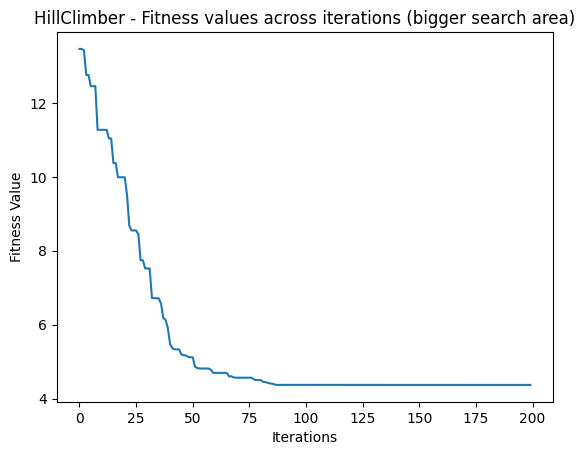

In [31]:
plot.plot(big_search_fitness_vals)
plot.title('HillClimber - Fitness values across iterations (bigger search area)')
plot.xlabel('Iterations')
plot.ylabel('Fitness Value')
plot.show()

In [ ]:
"""Evolutionary algorithm."""
def evolutionary_algorithm(no_iterations, best_x, worst_x, best_y, worst_y, pop_size):
    population = []
    array_fitness_vals = []
    
    